In [1]:
from pathlib import Path

import h5py
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap


In [2]:
# Change these values, then rerun this cell and the plotting cells below.
FONT_FAMILY = "Arial"  # Choose an installed font, e.g. "Arial" or "Times New Roman".
FONT_SIZE = 18  # points

plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "savefig.dpi": 600,  # High resolution for exported images.
    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "legend.title_fontsize": FONT_SIZE,
    "figure.titlesize": FONT_SIZE,
})

In [3]:
LUMERICAL_DATA_DIR = Path(
    "/Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/"
    "My Drive/Ming Wu Integrated Photonics Group/Simulations/Lumerical/"
    "Integrated_Trapped_Ions_Library/Gen2_pub")

In [4]:
EXPERIMENT_MAT_PATH = '/Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/My Drive/Ming Wu Integrated Photonics Group/Experiments/Measurements/3-6-ba2-processed_re/Global/635/Imported_frames.mat'
# Import only this measured image plane (units: micrometres).
REQUESTED_HEIGHT_UM = 90.0

EXPERIMENT_MAT_PATH_450 = '/Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/My Drive/Ming Wu Integrated Photonics Group/Experiments/Measurements/3-6-ba2-processed_re/Global/450/Imported_frames.mat'

In [5]:
def import_experiment_mat(mat_path, requested_height_um, height_tolerance_um=1e-6):
    """Read one measured plane from an Imported_frames.mat file.

    Uses this experiment's #refs#/v, q, r, p layout. Coordinates and heights
    are in micrometres; image values are unchanged and arranged as (y, x).
    Requires exactly one height match within height_tolerance_um and loads
    only that plane, not the full image stack. Returns a dictionary.
    """
    mat_path = Path(mat_path).expanduser()
    with h5py.File(mat_path, "r") as mat_file:
        heights_um = mat_file["#refs#/v"][:, 0]
        x_um = mat_file["#refs#/q"][:, 0]
        y_um = mat_file["#refs#/r"][:, 0]
        stack = mat_file["#refs#/p"]

        expected_shape = (len(heights_um), len(x_um), len(y_um))
        if stack.shape != expected_shape:
            raise ValueError("The image stack and coordinate lengths do not agree.")

        height_matches = np.flatnonzero(np.isclose(
            heights_um, requested_height_um, rtol=0, atol=height_tolerance_um
        ))
        if len(height_matches) != 1:
            raise ValueError(
                f"Expected one measured plane at {requested_height_um:g} µm; "
                f"found {len(height_matches)} matches."
            )

        height_index = int(height_matches[0])
        height_um = float(heights_um[height_index])
        image = stack[height_index, :, :].T

    return {
        "x_um": x_um,
        "y_um": y_um,
        "image": image,
        "height_um": height_um,
        "height_index": height_index,
        "heights_um": heights_um,
    }


In [6]:
# EXPERIMENTAL DATA — change the path and height in the settings cell above.
experiment_data = import_experiment_mat(EXPERIMENT_MAT_PATH, REQUESTED_HEIGHT_UM)

# Keep the variable names used by the plotting cells.
experiment_x_um = experiment_data["x_um"]
experiment_y_um = experiment_data["y_um"]
experiment_image = experiment_data["image"]
experiment_height_um = experiment_data["height_um"]
experiment_height_index = experiment_data["height_index"]
experiment_heights_um = experiment_data["heights_um"]

experiment_data = import_experiment_mat(EXPERIMENT_MAT_PATH_450, REQUESTED_HEIGHT_UM)

# Keep the variable names used by the plotting cells.
experiment_x_um_450 = experiment_data["x_um"]
experiment_y_um_450 = experiment_data["y_um"]
experiment_image_450 = experiment_data["image"]
experiment_height_um_450 = experiment_data["height_um"]
experiment_height_index_450 = experiment_data["height_index"]
experiment_heights_um_450 = experiment_data["heights_um"]


In [7]:
# EXTRACT AN X PROFILE AT A SPECIFIED Y POSITION

def extract_experiment_slice(image, x_um, y_um, y_value_um):
    """Return the intensity versus x at the measured y nearest y_value_um.

    image must have shape (len(y_um), len(x_um)); coordinates are in µm.
    Selects one row without interpolation, averaging, or normalization.
    Returns the actual selected y, its row index, and copies of the profile
    and x coordinates. Requests outside the measured y range raise an error.
    """
    image = np.asarray(image)
    x_um = np.asarray(x_um)
    y_um = np.asarray(y_um)
    y_value_um = float(y_value_um)

    if x_um.ndim != 1 or y_um.ndim != 1 or not x_um.size or not y_um.size:
        raise ValueError("x_um and y_um must be nonempty 1D coordinate arrays.")
    if image.shape != (y_um.size, x_um.size):
        raise ValueError("image must have shape (len(y_um), len(x_um)).")
    if not np.all(np.isfinite(y_um)) or not np.isfinite(y_value_um):
        raise ValueError("The y coordinates and requested y must be finite.")
    if not y_um.min() <= y_value_um <= y_um.max():
        raise ValueError(
            f"Requested y={y_value_um:g} µm is outside the measured range "
            f"[{y_um.min():g}, {y_um.max():g}] µm."
        )

    y_index = int(np.argmin(np.abs(y_um - y_value_um)))
    return {
        "x_um": x_um.copy(),
        "intensity": image[y_index, :].copy(),
        "y_um": float(y_um[y_index]),
        "requested_y_um": y_value_um,
        "y_index": y_index,
    }


In [16]:
# Example: extract the row nearest y = 0 µm.
profile_650 = extract_experiment_slice(
    experiment_image, experiment_x_um, experiment_y_um, y_value_um=0.0
)
print(f"Selected y = {profile_650['y_um']:.3f} µm")

line_cut_650 = profile_650['intensity'] / max(profile_650['intensity'])

print(experiment_x_um[line_cut_650==1])


profile_455 = extract_experiment_slice(
    experiment_image_450, experiment_x_um_450, experiment_y_um_450, y_value_um=0.0
)
print(f"Selected y = {profile_455['y_um']:.3f} µm")

line_cut_455 = profile_455['intensity'] / max(profile_455['intensity'])

print(experiment_x_um_450[line_cut_455==1])

Selected y = -0.013 µm
[-18.00811569 -17.89852241 -17.78892913 -17.67933585]
Selected y = 0.009 µm
[-18.3946888  -18.28466143 -18.06460669 -17.95457933]


In [9]:
def import_lumerical_mat(filename, data_dir=LUMERICAL_DATA_DIR, squeeze=True):
    """Load one numeric Lumerical MAT export into a dictionary of arrays.

    filename can be an absolute path or a path relative to data_dir.
    Restore MATLAB dimension order, preserve complex fields and original units,
    and optionally remove singleton dimensions (so x and y become 1D).
    Supports the flat numeric exports in Gen2_pub and older MAT files.
    """
    path = Path(filename).expanduser()
    if not path.is_absolute():
        path = Path(data_dir).expanduser() / path
    if not path.is_file():
        raise FileNotFoundError(f"MAT file not found: {path}")

    if not h5py.is_hdf5(path):
        return {
            name: value
            for name, value in loadmat(path, squeeze_me=squeeze).items()
            if not name.startswith("__")
        }

    data = {}
    with h5py.File(path, "r") as mat:
        for name, dataset in mat.items():
            if name.startswith("#"):
                continue
            if not isinstance(dataset, h5py.Dataset):
                raise TypeError(f"{name!r} is not a flat numeric dataset in {path}")
            values = dataset[()]
            if values.dtype.names and {"real", "imag"} <= set(values.dtype.names):
                values = values["real"] + 1j * values["imag"]
            # MATLAB stores HDF5 dimensions in reverse order.
            values = values.T
            data[name] = values.squeeze() if squeeze else values
    return data

In [25]:
# SIMULATION DATA
TE_650_sim_data = import_lumerical_mat("650nm/TE/XY_cut_96.mat")
x, y, P = TE_650_sim_data["x"], TE_650_sim_data["y"], TE_650_sim_data["P"]

#normalize the power
norm_P = P / P.max()

TE_455_sim_data = import_lumerical_mat("455nm/TE/XY_cut_96.mat")
x_455, y_455, P_455 = TE_455_sim_data["x"], TE_455_sim_data["y"], TE_455_sim_data["P"]

#normalize the power
norm_P_455 = P_455 / P_455.max()

In [11]:
# Experimental black-circle markers digitized from 650nm_axial_profile (3).png.
# Approximate image-derived values, not the original measurement data.
# Columns: axial position (µm), normalized intensity, lower error, upper error.
# Errors reproduce the plotted vertical bars; their statistical meaning is unknown.
# At x ≈ -33.18 µm the lower cap is clipped; its extent assumes a symmetric bar.
# Calibration: x = (pixel_x - 1584.5) / 28.5; y uses the labeled 0.0–1.0 ticks.
axial_650_points = np.array([
    [-36.05, 0.0335, 0.0202, 0.0202],
    [-33.18, 0.0188, 0.0179, 0.0179],
    [-30.33, 0.0529, 0.0145, 0.0145],
    [-27.46, 0.0535, 0.0164, 0.0164],
    [-24.58, 0.0757, 0.0130, 0.0130],
    [-21.70, 0.0559, 0.0213, 0.0213],
    [-18.86, 0.0759, 0.0098, 0.0098],
    [-15.98, 0.0712, 0.0047, 0.0047],
    [-13.11, 0.0725, 0.0204, 0.0204],
    [-10.26, 0.2781, 0.0473, 0.0473],
    [-7.39, 0.4691, 0.0581, 0.0581],
    [-4.51, 0.6281, 0.0613, 0.0613],
    [-1.63, 0.8867, 0.0130, 0.0130],
    [1.70, 0.9978, 0.0181, 0.0181],
    [4.58, 0.7586, 0.0654, 0.0654],
    [7.42, 0.4861, 0.0790, 0.0790],
    [10.30, 0.3103, 0.0330, 0.0330],
    [13.18, 0.1461, 0.0145, 0.0145],
    [16.05, 0.1168, 0.0128, 0.0128],
    [18.89, 0.1534, 0.0166, 0.0166],
    [21.77, 0.1604, 0.0134, 0.0134],
    [24.40, 0.1263, 0.0134, 0.0134],
    [26.79, 0.1568, 0.0209, 0.0209],
    [29.18, 0.0893, 0.0398, 0.0398],
])

axial_650_x_um = axial_650_points[:, 0]
axial_650_intensity = axial_650_points[:, 1]
axial_650_yerr = axial_650_points[:, 2:4].T  # Shape (2, number of points).
axial_650_errorbar_estimated = np.zeros(len(axial_650_points), dtype=bool)
axial_650_errorbar_estimated[1] = True  # Lower cap clipped by the plot boundary.



In [12]:
# 455 NM EXPERIMENTAL POINTS — digitized from the supplied "455 Beam Waist Scan".
# Approximate manual readings from the displayed image, not raw measurements.
# Columns: axial position (µm), normalized intensity, lower error, upper error.
# Errors approximate the plotted symmetric vertical bars; no statistical meaning
# (e.g. standard deviation) is assumed. Small caps overlap the circular markers,
# so the flagged error-bar estimates below are particularly uncertain.
# Image calibration (2048 × 1211 display): x = (px - 584.8) / 17.615;
# intensity = (1089.4 - py) / 937.1. No fitted-curve points are included.
axial_455_points = np.array([
    [-23.07, 0.033, 0.007, 0.007],
    [-15.06, 0.101, 0.014, 0.014],
    [-11.65, 0.136, 0.014, 0.014],
    [-7.08, 0.277, 0.022, 0.022],
    [0.32, 1.000, 0.045, 0.045],
    [4.34, 0.619, 0.041, 0.041],
    [8.91, 0.157, 0.014, 0.014],
    [12.92, 0.209, 0.021, 0.021],
    [15.20, 0.255, 0.018, 0.018],
    [18.05, 0.216, 0.021, 0.021],
    [21.48, 0.037, 0.007, 0.007],
    [24.90, 0.031, 0.007, 0.007],
    [27.19, 0.026, 0.007, 0.007],
    [31.76, 0.026, 0.007, 0.007],
    [36.33, 0.047, 0.007, 0.007],
    [40.90, 0.033, 0.008, 0.008],
])

axial_455_x_um = axial_455_points[:, 0]
axial_455_intensity = axial_455_points[:, 1]
axial_455_yerr = axial_455_points[:, 2:4].T
axial_455_errorbar_uncertain = np.zeros(len(axial_455_points), dtype=bool)
axial_455_errorbar_uncertain[[0, 10, 11, 12, 13, 14, 15]] = True



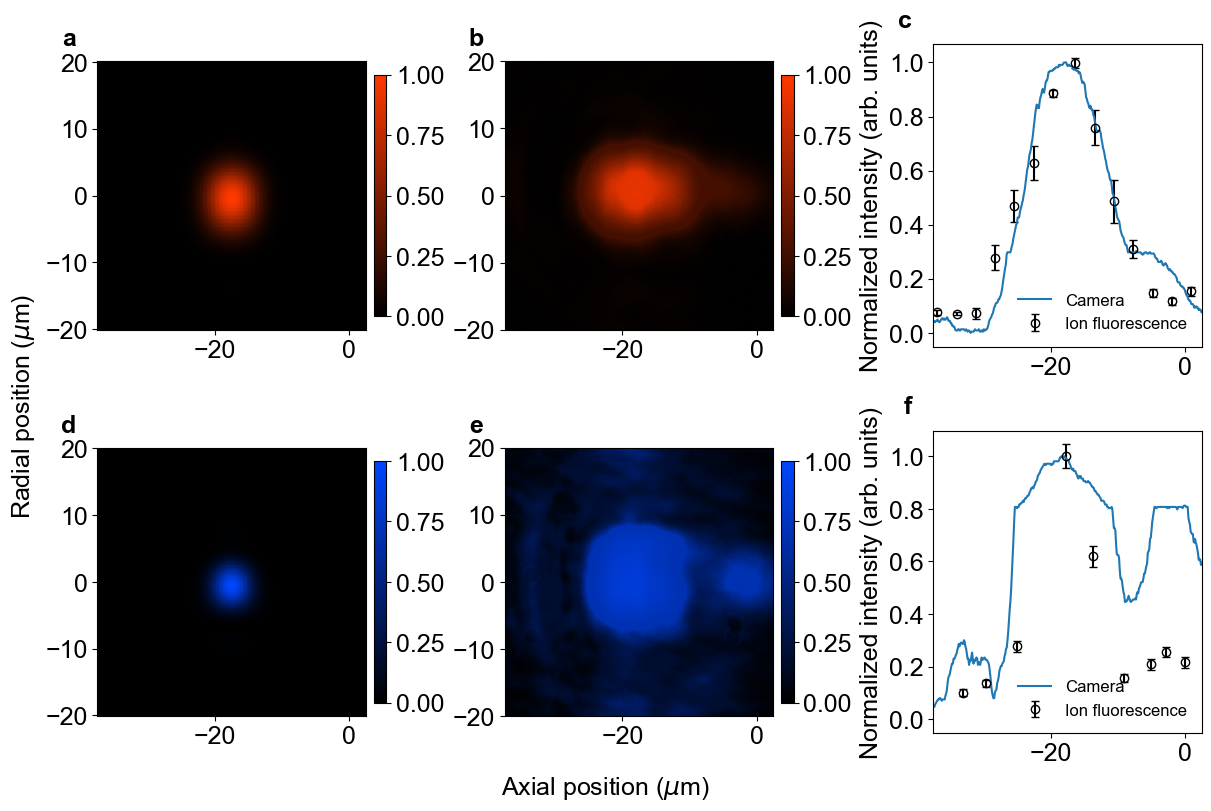

In [ ]:
# Choose the subplot grid and the size of each panel (in inches).
N_ROWS = 2
N_COLS = 3
PANEL_WIDTH = 4
PANEL_HEIGHT = 4

fig = plt.figure(
    figsize=(N_COLS * PANEL_WIDTH, N_ROWS * PANEL_HEIGHT),
    dpi=100,
    constrained_layout=True,
)

rows = fig.subfigures(nrows=N_ROWS, ncols=1, squeeze=False)[:, 0]
axes = np.vstack([
    row.subplots(1, N_COLS, squeeze=False)
    for row in rows
])

# rows[0].supxlabel("Axial offset (µm)", fontsize=FONT_SIZE)
# rows[0].supylabel("Radial offset (µm)", fontsize=FONT_SIZE)

# Increasing intensity appears as increasing brightness of the chosen red.
cmap_635 = LinearSegmentedColormap.from_list("635_nm", ["black", "#ff3900"])
cmap_450 = LinearSegmentedColormap.from_list("450_nm", ["black", "#0046ff"])

ax = axes[0, 0]
im = ax.pcolormesh(
    x * 1e6 + 19, y * 1e6, norm_P,
    shading="nearest", cmap=cmap_635, vmin=0, vmax=1,
)
fig.colorbar(
    im, ax=ax,
    shrink=0.8,  # Colorbar length relative to the panel
    pad=0.03,   # Gap between panel and colorbar
)
ax.set_aspect("equal")


ax = axes[0, 1]
im_1 = ax.pcolormesh(
    experiment_x_um, experiment_y_um, experiment_image,
    shading="nearest", cmap=cmap_635, vmin=0, vmax=1,
)
ax.set_aspect("equal")

fig.colorbar(
    im_1, ax=ax,
    shrink=0.8,  # Colorbar length relative to the panel
    pad=0.03,   # Gap between panel and colorbar
)
ax.set_aspect("equal")
ax.set_xlim([min(x * 1e6 + 19), max(x * 1e6 + 19)])
ax.set_ylim([min(y * 1e6), max(y * 1e6)])

# Example for a subplot (put before plt.show() in your layout cell):
ax = axes[0, 2]
ax.errorbar(axial_650_x_um-18, axial_650_intensity, yerr=axial_650_yerr,
            fmt="o", mfc="none", color="black", capsize=3, label="Ion fluorescence")
ax.plot(experiment_x_um, line_cut_650, label="Camera")
ax.set_ylabel("Normalized intensity (arb. units)")
ax.set_xlim([min(x * 1e6 + 19), max(x * 1e6 + 19)])
ax.legend(loc="best", fontsize=12, frameon=False)

ax = axes[1, 0]
im = ax.pcolormesh(
    x_455 * 1e6 + 19, y_455 * 1e6, norm_P_455,
    shading="nearest", cmap=cmap_450, vmin=0, vmax=1,
)
fig.colorbar(
    im, ax=ax,
    shrink=0.8,  # Colorbar length relative to the panel
    pad=0.03,   # Gap between panel and colorbar
)
ax.set_aspect("equal")

ax = axes[1, 1]
im_3 = ax.pcolormesh(
    experiment_x_um_450, experiment_y_um_450, experiment_image_450,
    shading="nearest", cmap=cmap_450, vmin=0, vmax=1,
)
ax.set_aspect("equal")

fig.colorbar(
    im_3, ax=ax,
    shrink=0.8,  # Colorbar length relative to the panel
    pad=0.03,   # Gap between panel and colorbar
)
ax.set_aspect("equal")
ax.set_xlim([min(x * 1e6 + 19), max(x * 1e6 + 19)])
ax.set_ylim([min(y * 1e6), max(y * 1e6)])

ax = axes[1, 2]
ax.errorbar(axial_455_x_um-18, axial_455_intensity, yerr=axial_455_yerr,
            fmt="o", mfc="none", color="black", capsize=3,
            label="Ion fluorescence")
ax.plot(experiment_x_um_450, line_cut_455, label="Camera")
ax.set_xlim([min(x * 1e6 + 19), max(x * 1e6 + 19)])
ax.legend(loc="best", fontsize=12, frameon=False)
ax.set_ylabel("Normalized intensity (arb. units)")
fig.supxlabel("Axial position ($\mu$m)", fontsize=FONT_SIZE)
fig.supylabel("Radial position ($\mu$m)", fontsize=FONT_SIZE)

# Bold panel labels, ordered left to right and then top to bottom.
PANEL_LABEL_SIZE = 18
PANEL_LABEL_POSITION = (-0.08, 1.04)  # Axes coordinates; (0, 1) is upper-left.

for panel_label, panel_ax in zip("abcdefghijklmnopqrstuvwxyz", axes.flat):
    panel_ax.text(
        *PANEL_LABEL_POSITION, panel_label,
        transform=panel_ax.transAxes,
        fontsize=PANEL_LABEL_SIZE, fontweight="bold",
        ha="right", va="bottom", color="black",
        clip_on=False,
    )

plt.show()
